## SETUP

In [28]:
import sys
import subprocess

# Install required packages for this notebook
required_packages = ["torch", "torchvision", "torchaudio", "soundfile", "matplotlib"]
for pkg in required_packages:
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print(f"Installed {pkg}")

import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import math

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class SpeechDigitDataset(Dataset):
    def __init__(self, data_dir, is_train=True, audio_aug=False, img_aug=False):
        self.data_dir = data_dir
        self.filepaths = []
        self.labels = []
        self.audio_aug = audio_aug
        self.img_aug = img_aug

        subset_dir = 'Train' if is_train else 'Test'
        full_subset_path = os.path.join(data_dir, subset_dir)
        if not os.path.exists(full_subset_path):
            print(f"Warning: Directory not found: {full_subset_path}")
        else:
            for file in os.listdir(full_subset_path):
                if file.endswith('.wav'):
                    filepath = os.path.join(full_subset_path, file)
                    self.filepaths.append(filepath)
                    try:
                        label = int(file.split('_')[1].split('.')[0])
                        self.labels.append(label)
                    except (IndexError, ValueError):
                        pass

        self.spectrogramer = T.MelSpectrogram(sample_rate=16000, n_mels=64)
        self.resize = transforms.Resize((32, 32))
        # Reduced SpecAugment parameters to avoid over-augmentation
        self.freq_mask = T.FrequencyMasking(freq_mask_param=7)
        self.time_mask = T.TimeMasking(time_mask_param=7)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]
        waveform, sample_rate = torchaudio.load(path)

        if self.audio_aug:
            noise = torch.randn_like(waveform) * 0.002
            waveform = waveform + noise

        spec = self.spectrogramer(waveform)
        spec = torchaudio.transforms.AmplitudeToDB()(spec)
        spec = self.resize(spec)

        if self.img_aug:
            # Apply Spectrum Augmentation (SpecAugment) - reduced intensity
            spec = self.freq_mask(spec)
            spec = self.time_mask(spec)

        return spec, label

Using device: cuda


In [29]:
print('Installing ffmpeg...')
!apt-get -qq install ffmpeg
print('ffmpeg installed.')

Installing ffmpeg...
ffmpeg installed.


## **1: Setup and Environment**

In [30]:
import sys
import subprocess

# Install required packages for this notebook
required_packages = ["torch", "torchvision", "torchaudio", "matplotlib"]
for pkg in required_packages:
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print(f"Installed {pkg}")


In [31]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import math

# Google Colab Drive mounting (commented out for local use)
# from google.colab import drive
# drive.mount('/content/drive')

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [32]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import math

# Google Colab Drive mounting (commented out for local use)
from google.colab import drive
drive.mount('/content/drive')

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [33]:
import sys
import subprocess

print("Python executable:", sys.executable)
print("Python version:", sys.version)

# Ensure required packages are installed in the current kernel environment
required_packages = ["torch", "torchvision", "torchaudio"]
for pkg in required_packages:
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print(f"Installed {pkg}")


Python executable: /usr/bin/python3
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


# **Question 2 - Preparing ReducedMNIST**

**Objective**: Create a "ReducedMNIST" dataset with 1000 training examples and 200 testing examples per digit.

We will download the standard MNIST dataset and use PyTorch's Subset to randomly sample the exact number of examples required. We also apply a basic ToTensor() transform to convert the images to PyTorch tensors.


In [34]:
def get_reduced_mnist(train_samples_per_class=1000, test_samples_per_class=200):
    transform = transforms.Compose([transforms.ToTensor()])

    # Download full MNIST
    full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    full_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    # Helper function to get balanced subsets
    def create_subset(dataset, samples_per_class):
        indices = []
        targets = dataset.targets.numpy()
        for i in range(10): # 10 digits
            class_indices = np.where(targets == i)[0]
            np.random.shuffle(class_indices)
            indices.extend(class_indices[:samples_per_class])
        return Subset(dataset, indices)

    reduced_train = create_subset(full_train, train_samples_per_class)
    reduced_test = create_subset(full_test, test_samples_per_class)

    return reduced_train, reduced_test

train_set, test_set = get_reduced_mnist()
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print(f"Reduced Train size: {len(train_set)} | Reduced Test size: {len(test_set)}")

Reduced Train size: 10000 | Reduced Test size: 2000


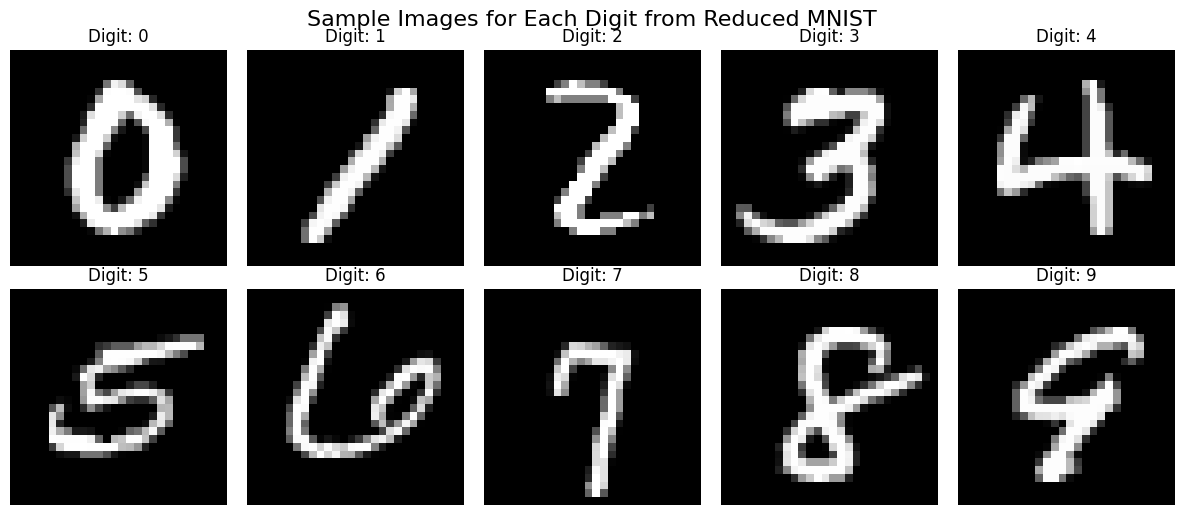

In [35]:
# Collect one sample image for each digit (0-9)
samples_per_digit = {}
for image, label in train_set:
    if label not in samples_per_digit:
        samples_per_digit[label] = image.squeeze().numpy() # Remove channel dim and convert to numpy
    if len(samples_per_digit) == 10:
        break

# Sort samples by digit for consistent display
sorted_samples = sorted(samples_per_digit.items())

# Plot the sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, (label, image_np) in enumerate(sorted_samples):
    axes[i].imshow(image_np, cmap='gray')
    axes[i].set_title(f'Digit: {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle('Sample Images for Each Digit from Reduced MNIST', y=1.02, fontsize=16)
plt.show()

# **Question 2 - LeNet-5 Architecture & Training**
LoopObjective: Build a LeNet-5 model adjusted for $28\times28$ images.The standard LeNet expects $32\times32$. Without padding, a $5\times5$ convolution on a $28\times28$ image reduces it to $24\times24$. After pooling and a second convolution, the feature map flattens to 256. I've designed the class to accept different activations and filter counts so we can easily complete part "a" (variations).

In [36]:
class ModifiedLeNet5(nn.Module):
    def __init__(self, activation=nn.ReLU(), filter_1=6, filter_2=16, dropout=0.25, use_bn=True):
        super(ModifiedLeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, filter_1, kernel_size=5, stride=1)
        self.bn1 = nn.BatchNorm2d(filter_1) if use_bn else nn.Identity()
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(filter_1, filter_2, kernel_size=5, stride=1)
        self.bn2 = nn.BatchNorm2d(filter_2) if use_bn else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(filter_2 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.activation = activation

    def forward(self, x):
        x = self.pool(self.activation(self.bn1(self.conv1(x))))
        x = self.pool(self.activation(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(self.activation(self.fc1(x)))
        x = self.dropout(self.activation(self.fc2(x)))
        x = self.fc3(x)
        return x

def train_and_evaluate(model, train_loader, test_loader, epochs=10, lr=0.001, scheduler_patience=3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=scheduler_patience, factor=0.5)

    print(f"Training for {epochs} epochs...")

    train_losses = []
    test_accuracies = []
    test_losses = []

    start_total_train = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        correct = 0
        total = 0
        epoch_test_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                epoch_test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        avg_epoch_test_loss = epoch_test_loss / len(test_loader)
        test_losses.append(avg_epoch_test_loss)
        epoch_accuracy = 100 * correct / total
        test_accuracies.append(epoch_accuracy)
        print(f"  Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Accuracy: {epoch_accuracy:.2f}%, Test Loss: {avg_epoch_test_loss:.4f}")
        scheduler.step(epoch_accuracy)

    train_time = (time.time() - start_total_train) * 1000

    start_final_test = time.time()
    model.eval()
    correct = 0
    total = 0
    final_test_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            final_test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    final_test_time = (time.time() - start_final_test) * 1000
    final_accuracy = 100 * correct / total
    avg_final_test_loss = final_test_loss / len(test_loader)
    print(f"Final Test Accuracy: {final_accuracy:.2f}% | Final Test Loss: {avg_final_test_loss:.4f} | Total Test Time: {final_test_time:.1f} ms")

    return final_accuracy, train_time, final_test_time, train_losses, test_accuracies, test_losses

In [37]:
import matplotlib.pyplot as plt

def plot_learning_curves(experiment_results):
    num_experiments = len(experiment_results)
    if num_experiments == 0:
        print("No experiment results to plot.")
        return

    # Adjust figure size for two columns per experiment
    fig, axes = plt.subplots(num_experiments, 2, figsize=(15, 5 * num_experiments), squeeze=False)

    for i, (exp_name, results) in enumerate(experiment_results.items()):
        train_losses = results['train_losses']
        test_losses = results['test_losses']  # Get test_losses
        test_accuracies = results['test_accuracies']
        epochs = range(1, len(train_losses) + 1)

        # --- Plot 1: Training Loss and Test Loss ---
        ax_loss = axes[i, 0]
        ax_loss.plot(epochs, train_losses, label='Training Loss', marker='o', linestyle='-', color='tab:blue')
        ax_loss.plot(epochs, test_losses, label='Test Loss', marker='x', linestyle='--', color='tab:green')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.set_title(f'{exp_name} - Loss Curves')
        ax_loss.grid(True)
        ax_loss.legend(loc='best')

        # --- Plot 2: Test Accuracy ---
        ax_accuracy = axes[i, 1]
        ax_accuracy.plot(epochs, test_accuracies, label='Test Accuracy', marker='o', linestyle='-', color='tab:red')
        ax_accuracy.set_xlabel('Epoch')
        ax_accuracy.set_ylabel('Accuracy (%)')
        ax_accuracy.set_title(f'{exp_name} - Test Accuracy')
        ax_accuracy.grid(True)
        ax_accuracy.legend(loc='best')

    plt.tight_layout()
    plt.show()

# **Running Base Model & Variations (Q2.a)**

Objective: Run the base model using ReLU, then run two variations.

**Variation 1**: Swap ReLU for Tanh (changing activation).

**Variation 2**: Double the number of filters in the Convolutional layers.

**Variation 3**:
**Variation 4**:


--- Base Model (ReLU, Filters: 6 & 16) ---
Training for 10 epochs...
  Epoch 1/10, Train Loss: 0.7390, Test Accuracy: 95.70%, Test Loss: 0.1461
  Epoch 2/10, Train Loss: 0.1777, Test Accuracy: 97.20%, Test Loss: 0.0896
  Epoch 3/10, Train Loss: 0.1205, Test Accuracy: 97.20%, Test Loss: 0.0858
  Epoch 4/10, Train Loss: 0.0918, Test Accuracy: 97.80%, Test Loss: 0.0771
  Epoch 5/10, Train Loss: 0.0833, Test Accuracy: 98.05%, Test Loss: 0.0618
  Epoch 6/10, Train Loss: 0.0690, Test Accuracy: 98.00%, Test Loss: 0.0658
  Epoch 7/10, Train Loss: 0.0683, Test Accuracy: 97.85%, Test Loss: 0.0618
  Epoch 8/10, Train Loss: 0.0510, Test Accuracy: 98.00%, Test Loss: 0.0598
  Epoch 9/10, Train Loss: 0.0478, Test Accuracy: 97.90%, Test Loss: 0.0610
  Epoch 10/10, Train Loss: 0.0357, Test Accuracy: 98.25%, Test Loss: 0.0501
Final Test Accuracy: 98.25% | Final Test Loss: 0.0501 | Total Test Time: 238.5 ms
Accuracy: 98.2% | Train Time: 18614.4 ms | Test Time: 238.5 ms

--- Variation 1: Tanh Activation -

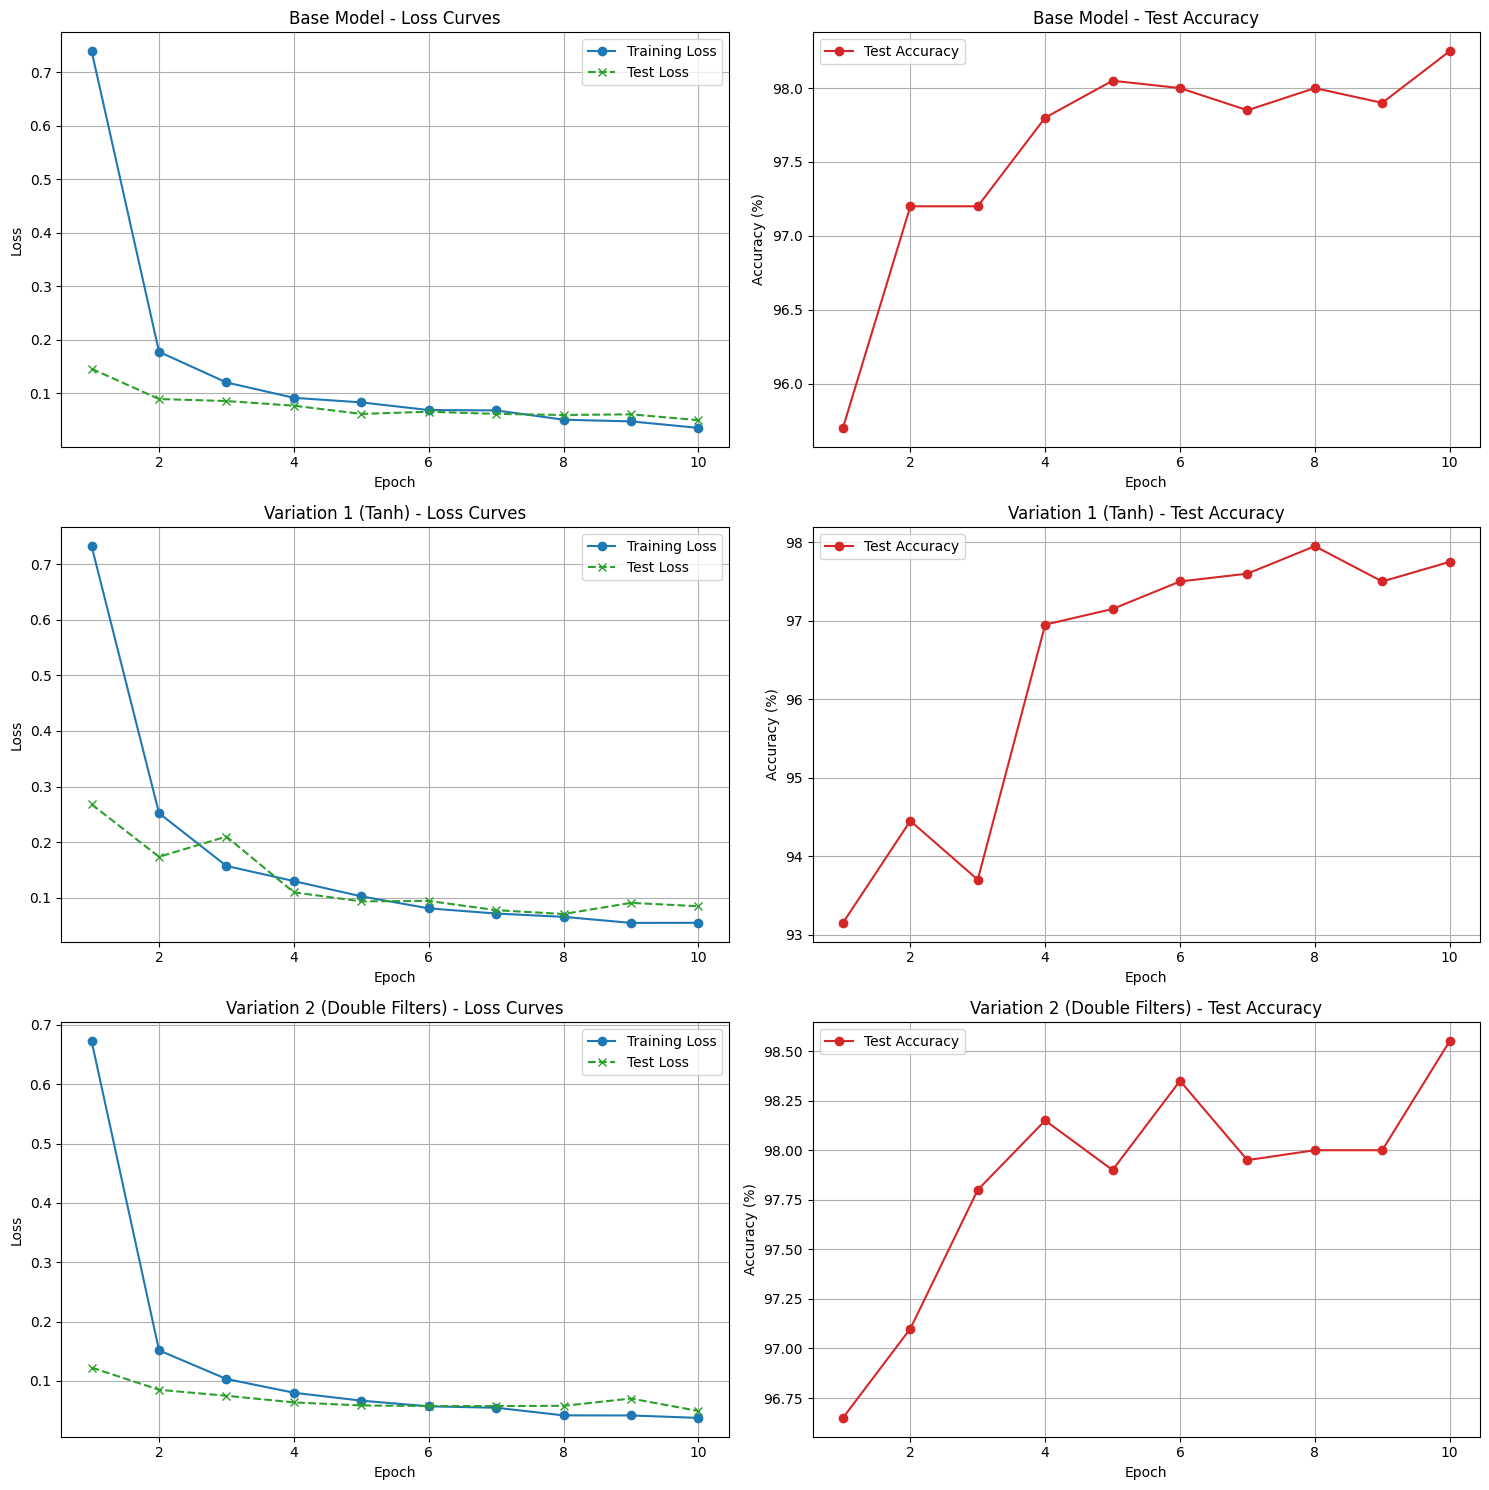

In [38]:
print("--- Base Model (ReLU, Filters: 6 & 16) ---")
base_model = ModifiedLeNet5(activation=nn.ReLU())
acc_base, train_t_base, test_t_base, train_losses_base, test_accuracies_base, test_losses_base = train_and_evaluate(base_model, train_loader, test_loader)
print(f"Accuracy: {acc_base:.1f}% | Train Time: {train_t_base:.1f} ms | Test Time: {test_t_base:.1f} ms\n")

print("--- Variation 1: Tanh Activation ---")
var1_model = ModifiedLeNet5(activation=nn.Tanh())
acc_v1, train_t_v1, test_t_v1, train_losses_v1, test_accuracies_v1, test_losses_v1 = train_and_evaluate(var1_model, train_loader, test_loader)
print(f"Accuracy: {acc_v1:.1f}% | Train Time: {train_t_v1:.1f} ms | Test Time: {test_t_v1:.1f} ms\n")

print("--- Variation 2: Double Filters (12 & 32) ---")
var2_model = ModifiedLeNet5(activation=nn.ReLU(), filter_1=12, filter_2=32)
acc_v2, train_t_v2, test_t_v2, train_losses_v2, test_accuracies_v2, test_losses_v2 = train_and_evaluate(var2_model, train_loader, test_loader)
print(f"Accuracy: {acc_v2:.1f}% | Train Time: {train_t_v2:.1f} ms | Test Time: {test_t_v2:.1f} ms\n")

# Collect results for plotting
experiment_results_mnist = {
    "Base Model": {
        "train_losses": train_losses_base,
        "test_accuracies": test_accuracies_base,
        "test_losses": test_losses_base
    },
    "Variation 1 (Tanh)": {
        "train_losses": train_losses_v1,
        "test_accuracies": test_accuracies_v1,
        "test_losses": test_losses_v1
    },
    "Variation 2 (Double Filters)": {
        "train_losses": train_losses_v2,
        "test_accuracies": test_accuracies_v2,
        "test_losses": test_losses_v2
    }
}

# Plot the learning curves for LeNet-5 experiments
plot_learning_curves(experiment_results_mnist)

--- Base Model (ReLU, Filters: 6 & 16) ---
Training for 10 epochs...
  Epoch 1/10, Train Loss: 0.7860, Test Accuracy: 95.20%, Test Loss: 0.1798
  Epoch 2/10, Train Loss: 0.1924, Test Accuracy: 96.10%, Test Loss: 0.1180
  Epoch 3/10, Train Loss: 0.1328, Test Accuracy: 97.00%, Test Loss: 0.0936
  Epoch 4/10, Train Loss: 0.1030, Test Accuracy: 97.35%, Test Loss: 0.0912
  Epoch 5/10, Train Loss: 0.0873, Test Accuracy: 98.10%, Test Loss: 0.0699
  Epoch 6/10, Train Loss: 0.0803, Test Accuracy: 98.35%, Test Loss: 0.0708
  Epoch 7/10, Train Loss: 0.0633, Test Accuracy: 97.50%, Test Loss: 0.0724
  Epoch 8/10, Train Loss: 0.0563, Test Accuracy: 98.00%, Test Loss: 0.0682
  Epoch 9/10, Train Loss: 0.0506, Test Accuracy: 98.60%, Test Loss: 0.0486
  Epoch 10/10, Train Loss: 0.0444, Test Accuracy: 97.15%, Test Loss: 0.1100
Final Test Accuracy: 97.15% | Final Test Loss: 0.1100 | Total Test Time: 234.0 ms
--- Variation 1: Tanh Activation ---
Training for 10 epochs...
  Epoch 1/10, Train Loss: 0.7030, T

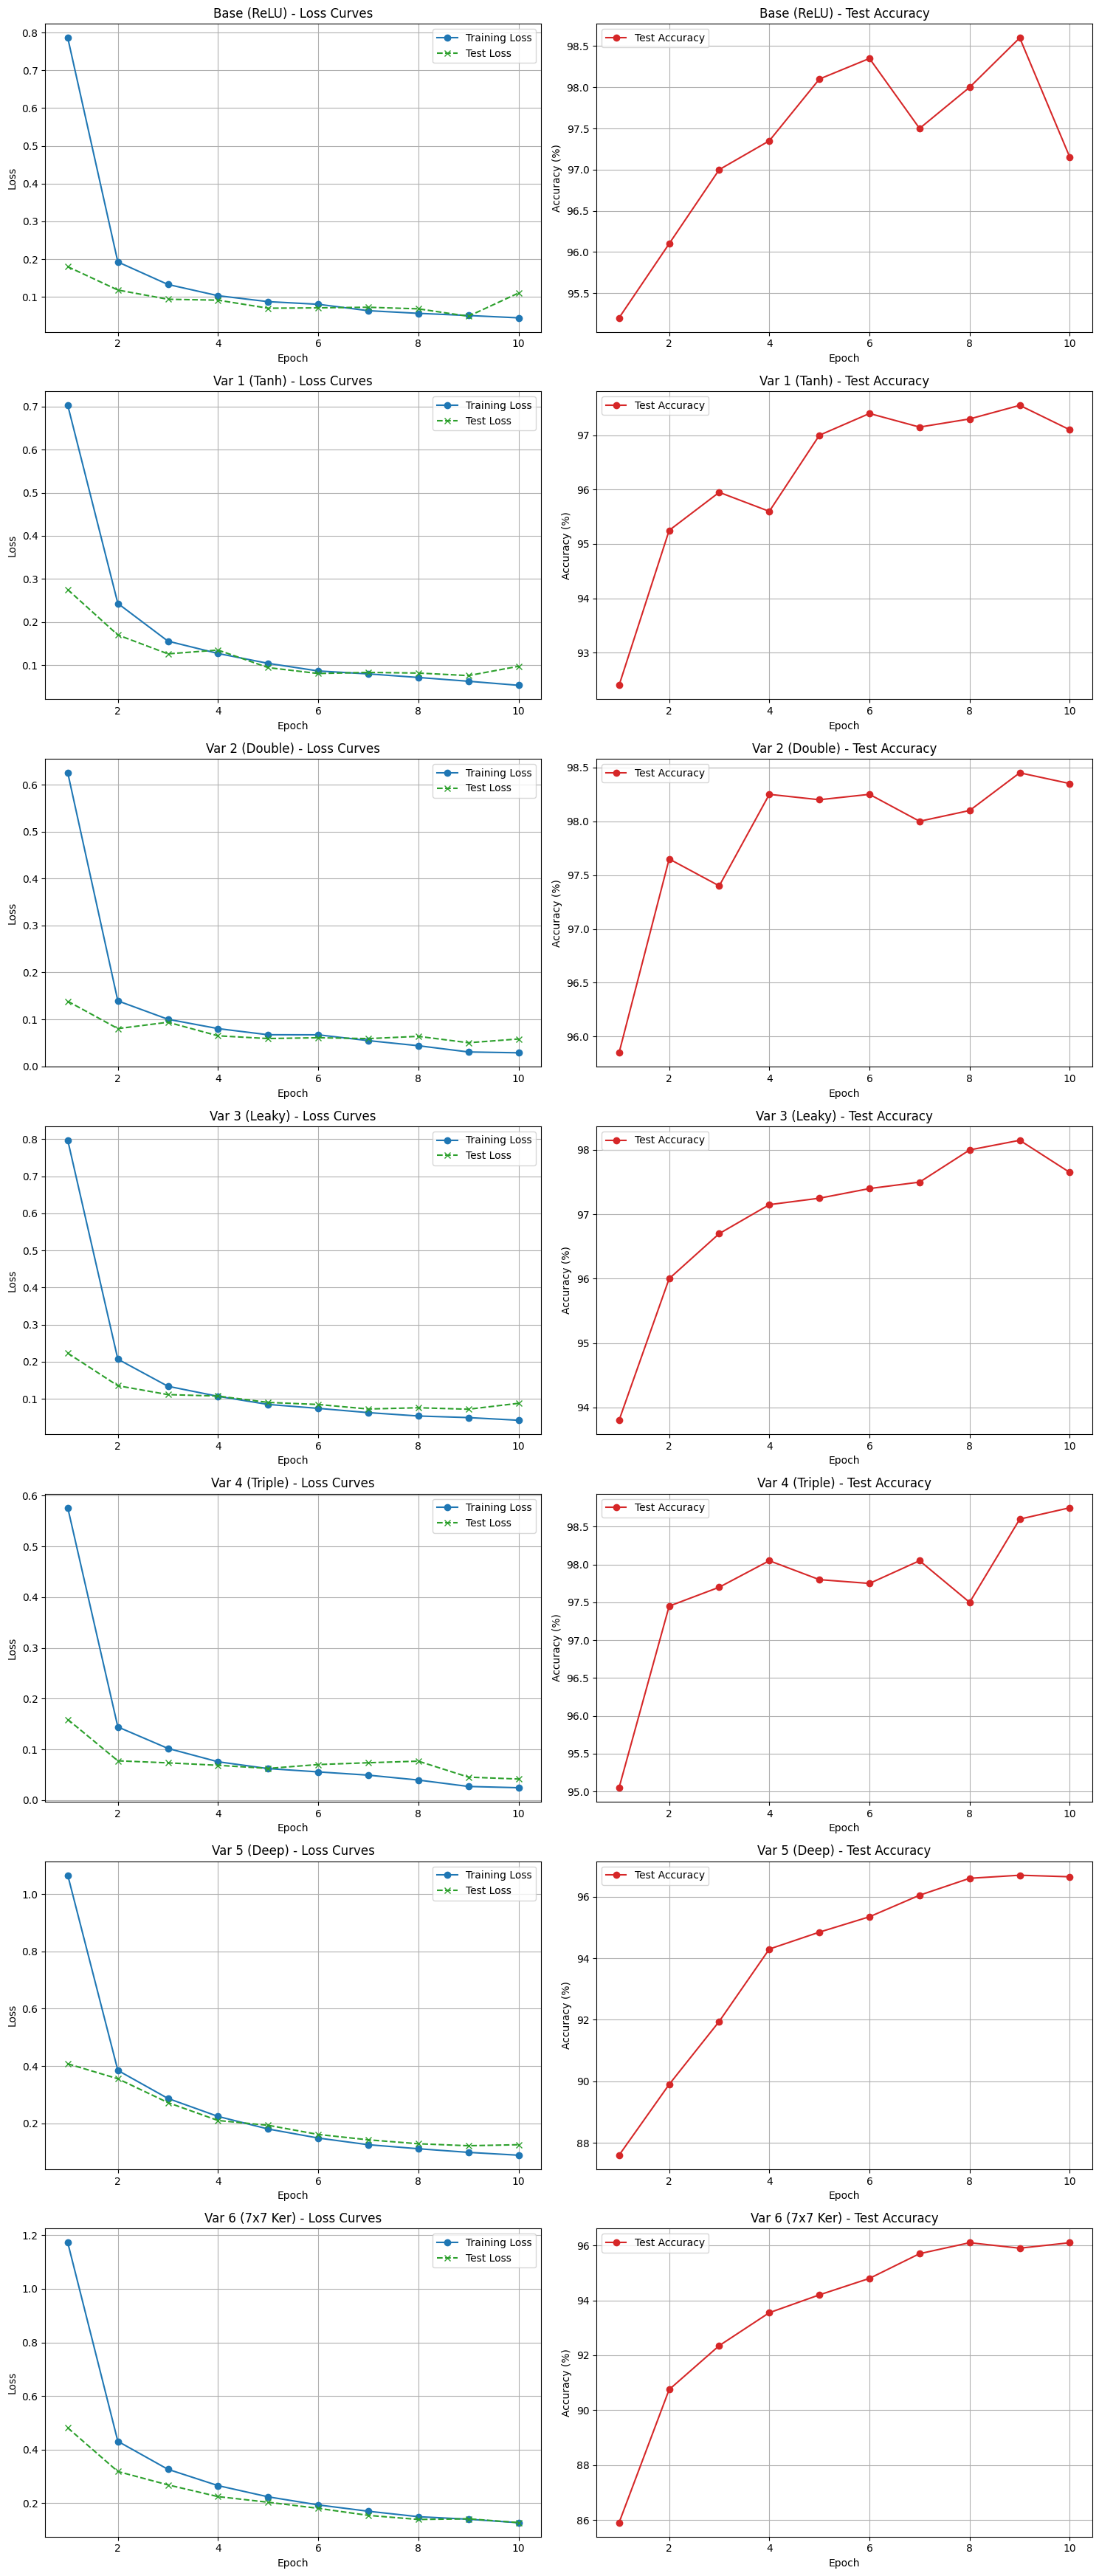

In [39]:
print("--- Base Model (ReLU, Filters: 6 & 16) ---")
base_model = ModifiedLeNet5(activation=nn.ReLU())
acc_base, train_t_base, test_t_base, train_losses_base, test_accuracies_base, test_losses_base = train_and_evaluate(base_model, train_loader, test_loader)

print("--- Variation 1: Tanh Activation ---")
var1_model = ModifiedLeNet5(activation=nn.Tanh())
acc_v1, train_t_v1, test_t_v1, train_losses_v1, test_accuracies_v1, test_losses_v1 = train_and_evaluate(var1_model, train_loader, test_loader)

print("--- Variation 2: Double Filters (12 & 32) ---")
var2_model = ModifiedLeNet5(activation=nn.ReLU(), filter_1=12, filter_2=32)
acc_v2, train_t_v2, test_t_v2, train_losses_v2, test_accuracies_v2, test_losses_v2 = train_and_evaluate(var2_model, train_loader, test_loader)

print("--- Variation 3: LeakyReLU Activation ---")
var3_model = ModifiedLeNet5(activation=nn.LeakyReLU())
acc_v3, _, _, train_losses_v3, test_accuracies_v3, test_losses_v3 = train_and_evaluate(var3_model, train_loader, test_loader)

print("--- Variation 4: Triple Filters (18 & 48) ---")
var4_model = ModifiedLeNet5(filter_1=18, filter_2=48)
acc_v4, _, _, train_losses_v4, test_accuracies_v4, test_losses_v4 = train_and_evaluate(var4_model, train_loader, test_loader)

# Fixed Variation 5: Calculated flat size for 28x28 input
class DeepLeNet(nn.Module):
    def __init__(self):
        super(DeepLeNet, self).__init__()
        self.c1 = nn.Conv2d(1, 6, 3, padding=1) # 28x28 -> pool -> 14x14
        self.c2 = nn.Conv2d(6, 16, 3, padding=1) # 14x14 -> pool -> 7x7
        self.c3 = nn.Conv2d(16, 32, 5) # 7x7 -> 3x3
        self.pool = nn.AvgPool2d(2, 2)
        self.fc = nn.Linear(32*3*3, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.c1(x)))
        x = self.pool(torch.relu(self.c2(x)))
        x = torch.relu(self.c3(x))
        return self.fc(x.view(x.size(0), -1))

print("--- Variation 5: Deep Architecture (3 Conv Layers) ---")
var5_model = DeepLeNet()
acc_v5, _, _, train_losses_v5, test_accuracies_v5, test_losses_v5 = train_and_evaluate(var5_model, train_loader, test_loader)

# Fixed Variation 6: Calculated flat size for 28x28 input
class LargeKernelLeNet(nn.Module):
    def __init__(self):
        super(LargeKernelLeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 7) # 28x28 -> 22x22 -> pool -> 11x11
        self.pool = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5) # 11x11 -> 7x7 -> pool -> 3x3
        self.fc = nn.Linear(16 * 3 * 3, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        return self.fc(x.view(x.size(0), -1))

var6_model = LargeKernelLeNet()
acc_v6, _, _, train_losses_v6, test_accuracies_v6, test_losses_v6 = train_and_evaluate(var6_model, train_loader, test_loader)

experiment_results_mnist = {
    "Base (ReLU)": {"train_losses": train_losses_base, "test_accuracies": test_accuracies_base, "test_losses": test_losses_base},
    "Var 1 (Tanh)": {"train_losses": train_losses_v1, "test_accuracies": test_accuracies_v1, "test_losses": test_losses_v1},
    "Var 2 (Double)": {"train_losses": train_losses_v2, "test_accuracies": test_accuracies_v2, "test_losses": test_losses_v2},
    "Var 3 (Leaky)": {"train_losses": train_losses_v3, "test_accuracies": test_accuracies_v3, "test_losses": test_losses_v3},
    "Var 4 (Triple)": {"train_losses": train_losses_v4, "test_accuracies": test_accuracies_v4, "test_losses": test_losses_v4},
    "Var 5 (Deep)": {"train_losses": train_losses_v5, "test_accuracies": test_accuracies_v5, "test_losses": test_losses_v5},
    "Var 6 (7x7 Ker)": {"train_losses": train_losses_v6, "test_accuracies": test_accuracies_v6, "test_losses": test_losses_v6}
}

plot_learning_curves(experiment_results_mnist)

#**Question 3 - Speech Recognition & Augmentation**

**Objective**: Convert speech .wav files into spectrograms and train a CNN.

Since you are mounting your Google Drive, we need a Custom Dataset class that can iterate through your folders, read the audio using torchaudio, and apply the requested augmentations.

NOTE to User: You must ensure your data_dir points to the correct folder in your drive where the .wav files are stored. The code assumes a folder structure where audio files are in subfolders named by their digit (e.g., .../audio-samples/0/xyz.wav).

In [40]:
# UPDATE THIS PATH to where your files are locally
YOUR_AUDIO_PATH = "/content/drive/MyDrive/SHARED/Assignments/NNs/audio-dataset"
class SpectrogramCNN(nn.Module):
    def __init__(self, dropout=0.3, use_bn=True):
        super(SpectrogramCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=5)
        self.bn1 = nn.BatchNorm2d(8) if use_bn else nn.Identity()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 24, kernel_size=5)
        self.bn2 = nn.BatchNorm2d(24) if use_bn else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(24 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        return self.fc3(x)

In [41]:
class SpectrogramCNN(nn.Module):
    def __init__(self, dropout=0.4, use_bn=True):
        super(SpectrogramCNN, self).__init__()
        # First Layer: Captures low-level frequency features
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) if use_bn else nn.Identity()
        self.pool = nn.MaxPool2d(2, 2)

        # Second Layer: Deeper feature extraction
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32) if use_bn else nn.Identity()

        # Third Layer: Increasing capacity for complex patterns
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64) if use_bn else nn.Identity()

        self.dropout = nn.Dropout(dropout)

        # Based on 32x32 input, 3 pools (2x2) = 4x4 feature map
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        return self.fc3(x)

Audio data path: /content/drive/MyDrive/SHARED/Assignments/NNs/audio-dataset
Number of fetched training audio samples: 1200
Number of fetched testing audio samples: 300


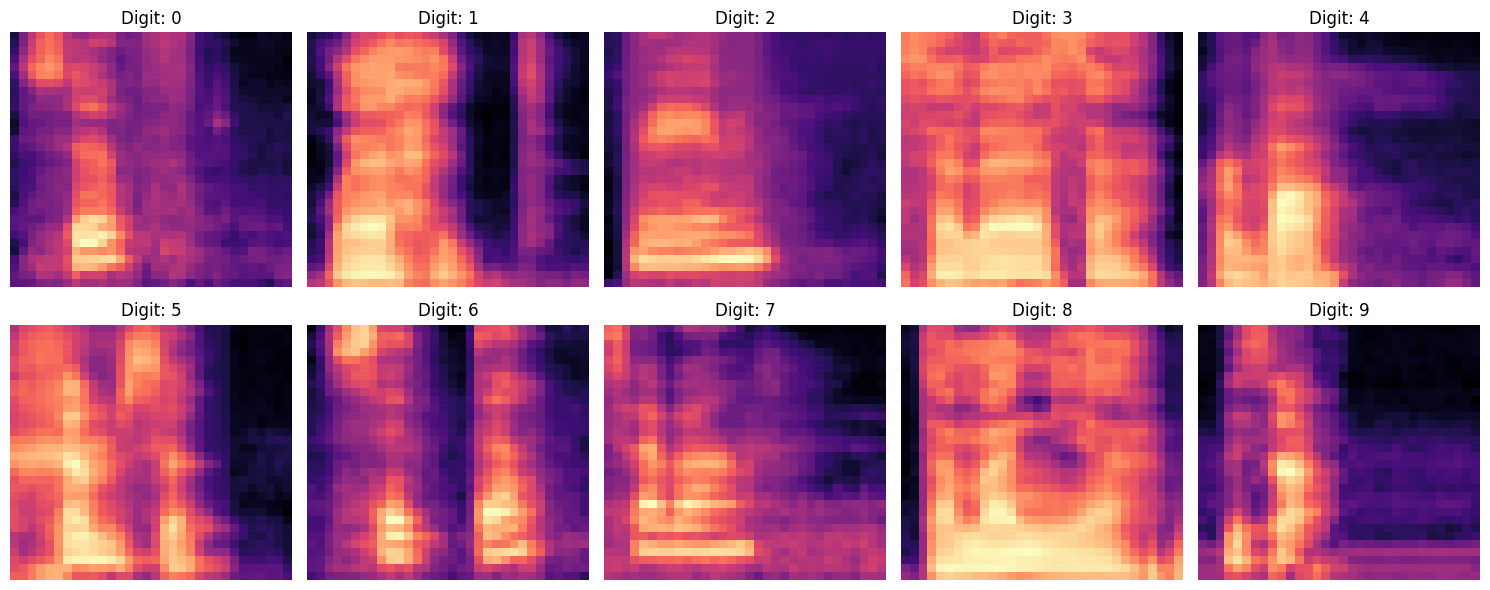

In [42]:
print(f"Audio data path: {YOUR_AUDIO_PATH}")

# Check if directory exists before proceeding
if not os.path.exists(YOUR_AUDIO_PATH):
    print(f"Error: The path {YOUR_AUDIO_PATH} does not exist. Please check your Google Drive folder structure.")
else:
    # Initialize datasets to count samples
    try:
        train_ds_info = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=True, audio_aug=False, img_aug=False)
        test_ds_info = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=False, audio_aug=False, img_aug=False)

        print(f"Number of fetched training audio samples: {len(train_ds_info)}")
        print(f"Number of fetched testing audio samples: {len(test_ds_info)}")

        if len(train_ds_info) == 0 or len(test_ds_info) == 0:
            print("Warning: One or both datasets are empty. Please check subdirectory names ('Train', 'Test') inside your Drive folder.")
    except Exception as e:
        print(f"An error occurred while loading dataset info: {e}")

# Visualization code remains available if data is found
if 'train_ds_info' in locals() and len(train_ds_info) > 0:
    vis_ds = train_ds_info
    samples_per_digit = {}
    for spec, label in vis_ds:
        if label not in samples_per_digit:
            samples_per_digit[label] = spec.squeeze().numpy()
        if len(samples_per_digit) == 10: break

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for i, (label, spec_np) in enumerate(sorted(samples_per_digit.items())):
        axes[i].imshow(spec_np, origin='lower', aspect='auto', cmap='magma')
        axes[i].set_title(f'Digit: {label}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

#**Running the 4 scenarios for Question 3**
**Objective**: Run experiments A, B, C, and D based on combinations of audio and image augmentations.(Note: The code below creates the datasets and triggers the training loop. If your dataset is large, consider reducing the number of epochs while testing).

In [43]:
def run_speech_experiment(audio_aug, img_aug, exp_name, epochs=20):
    print(f"\n--- Running Experiment: {exp_name} ---")
    train_ds = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=True, audio_aug=audio_aug, img_aug=img_aug)
    test_ds = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=False, audio_aug=False, img_aug=False)

    if len(train_ds) == 0:
        print("Warning: No audio files found. Check YOUR_AUDIO_PATH.")
        return None

    train_ldr = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_ldr = DataLoader(test_ds, batch_size=32, shuffle=False)

    model = SpectrogramCNN(dropout=0.3, use_bn=True).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    history = []
    best_acc = 0.0
    best_model_state = None
    save_dir = os.path.join(os.path.dirname(YOUR_AUDIO_PATH), "saved_models")
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        train_start = time.time()
        for images, labels in train_ldr:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_time = (time.time() - train_start) * 1000
        avg_train_loss = running_loss / len(train_ldr)

        # --- Testing ---
        model.eval()
        correct, total = 0, 0
        epoch_test_loss = 0.0
        test_start = time.time()
        with torch.no_grad():
            for images, labels in test_ldr:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                epoch_test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        test_time = (time.time() - test_start) * 1000

        avg_test_loss = epoch_test_loss / len(test_ldr)
        epoch_accuracy = 100 * correct / total
        history.append(epoch_accuracy)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, "
              f"Test Accuracy: {epoch_accuracy:.2f}%, LR: {current_lr:.6f}, "
              f"Train Time: {train_time:.1f}ms, Test Time: {test_time:.1f}ms")

        # Save best model
        if epoch_accuracy > best_acc:
            best_acc = epoch_accuracy
            best_model_state = model.state_dict().copy()

        scheduler.step()

    # Save the best model to disk
    safe_name = exp_name.replace(" ", "_").replace(":", "")
    save_path = os.path.join(save_dir, f"best_{safe_name}.pth")
    if best_model_state is not None:
        torch.save(best_model_state, save_path)
        print(f"Best model saved to {save_path} (Accuracy: {best_acc:.2f}%)")

    print(f"Final Best Accuracy: {best_acc:.2f}%")
    return {'history': history, 'best_acc': best_acc}

In [44]:
def plot_speech_results(results_dict):
    # 1. Comparison Bar Chart
    names = list(results_dict.keys())
    accuracies = [results_dict[n]['best_acc'] for n in names]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(names, accuracies, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
    plt.ylabel('Best Test Accuracy (%)')
    plt.title('Comparison of Augmentation Scenarios')
    plt.ylim(0, 100)

    # Add labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center')

    plt.tight_layout()
    plt.show()

    # 2. Learning Curves
    plt.figure(figsize=(14, 7))
    for name in names:
        plt.plot(results_dict[name]['history'], label=name, marker='o')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy Improvement Over Epochs')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Note: To use this, modify run_speech_experiment to return values or use this block after rerunning experiments to store data.

--- Starting All Experiments ---

--- Running Experiment: Scenario A: No Augmentation ---
  Epoch 1/30, Train Loss: 2.0721, Test Loss: 1.4947, Test Accuracy: 62.00%, LR: 0.001000, Train Time: 6915.5ms, Test Time: 1713.2ms
  Epoch 2/30, Train Loss: 1.1337, Test Loss: 0.5325, Test Accuracy: 88.00%, LR: 0.000997, Train Time: 7806.0ms, Test Time: 1681.0ms
  Epoch 3/30, Train Loss: 0.5721, Test Loss: 0.2409, Test Accuracy: 92.67%, LR: 0.000989, Train Time: 7859.9ms, Test Time: 1728.0ms
  Epoch 4/30, Train Loss: 0.3092, Test Loss: 0.1955, Test Accuracy: 92.67%, LR: 0.000976, Train Time: 6913.1ms, Test Time: 1807.1ms
  Epoch 5/30, Train Loss: 0.1719, Test Loss: 0.1778, Test Accuracy: 95.00%, LR: 0.000957, Train Time: 7684.2ms, Test Time: 1662.2ms
  Epoch 6/30, Train Loss: 0.1419, Test Loss: 0.0481, Test Accuracy: 98.33%, LR: 0.000934, Train Time: 7840.7ms, Test Time: 1682.9ms
  Epoch 7/30, Train Loss: 0.1099, Test Loss: 0.0803, Test Accuracy: 97.33%, LR: 0.000905, Train Time: 6873.0ms, Test T

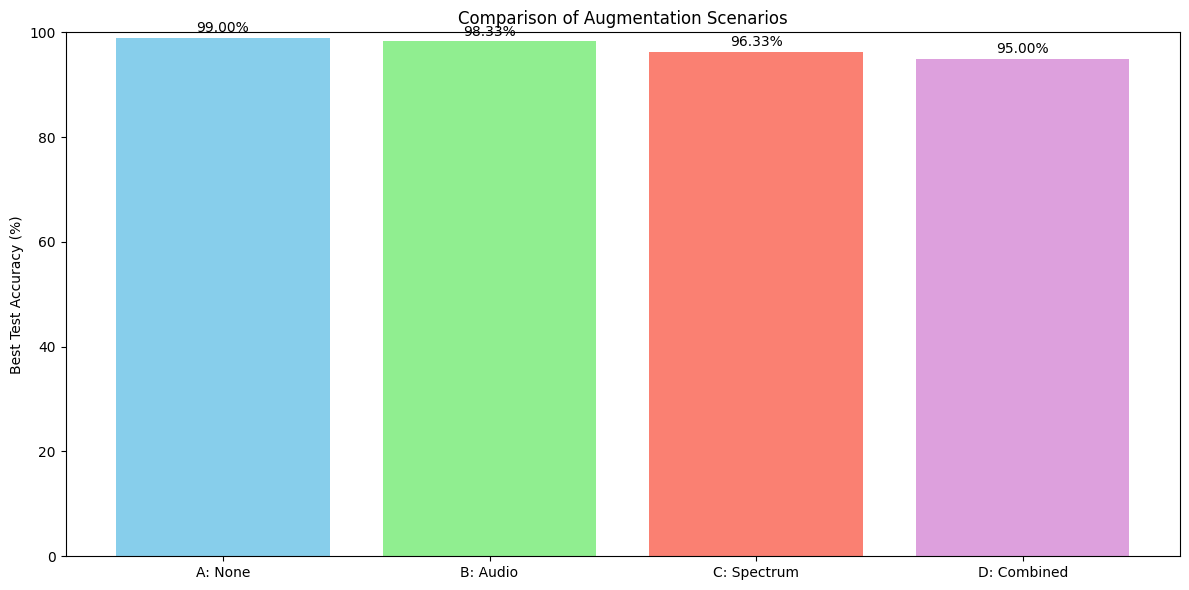

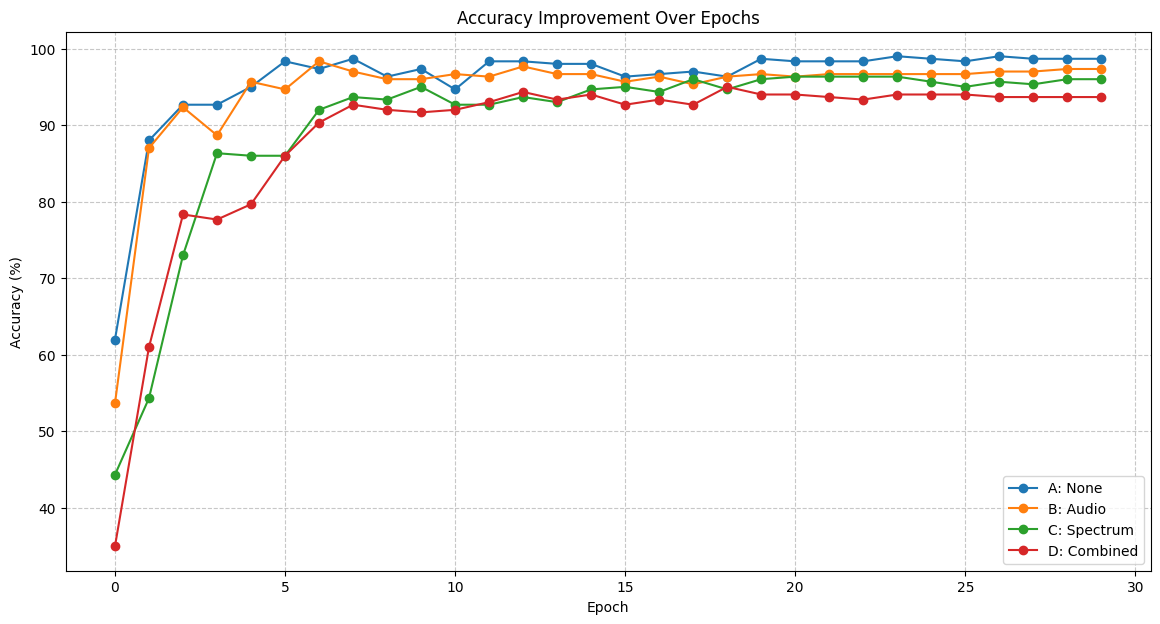

In [45]:
print("--- Starting All Experiments ---")
speech_results = {}

speech_results["A: None"] = run_speech_experiment(audio_aug=False, img_aug=False, exp_name="Scenario A: No Augmentation", epochs=30)
speech_results["B: Audio"] = run_speech_experiment(audio_aug=True, img_aug=False, exp_name="Scenario B: Audio Augmentation Only", epochs=30)
speech_results["C: Spectrum"] = run_speech_experiment(audio_aug=False, img_aug=True, exp_name="Scenario C: Spectrum Augmentation Only", epochs=30)
speech_results["D: Combined"] = run_speech_experiment(audio_aug=True, img_aug=True, exp_name="Scenario D: Combined Augmentation", epochs=30)

print("\n--- All Experiments Completed. Generating Graphs... ---")
final_speech_data = {k: v for k, v in speech_results.items() if v is not None}
if final_speech_data:
    plot_speech_results(final_speech_data)
else:
    print("No results to plot.")